In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)


from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from scipy import stats
import joblib
from tqdm import tqdm
from scipy.stats import kruskal


In [44]:
#Загружаем данные
df = pd.read_csv("C:/Users/Спасибо за покупку!/Documents/итоговый проект skillfactory/archive/CICIOT23/test/test.csv")

In [45]:
#Посмотрим информацию о нашем датасете
df.head()

,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,5.018181,125.82,6.00,64.00,0.471037,0.471037,0.0,0.0,1.0,0.0,...,0.00000,54.00,8.336227e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DDoS-SynonymousIP_Flood
1,0.000000,0.00,47.00,64.00,4.992473,4.992473,0.0,0.0,0.0,0.0,...,0.00000,592.00,8.367746e+07,9.5,34.409301,0.000000,0.000000,0.00,141.55,Mirai-greeth_flood
2,0.000000,55.22,6.05,65.27,31.735421,31.735421,0.0,0.0,0.0,0.0,...,0.77612,55.82,8.306829e+07,9.5,10.409427,1.111579,30.890194,0.02,141.55,DDoS-TCP_Flood
3,0.008299,5213.00,17.00,64.00,19365.300906,19365.300906,0.0,0.0,0.0,0.0,...,0.00000,50.00,8.310303e+07,9.5,10.000000,0.000000,0.000000,0.00,141.55,DDoS-UDP_Flood
4,4.672666,108.00,6.00,64.00,0.428021,0.428021,0.0,0.0,0.0,0.0,...,0.00000,54.00,8.295115e+07,9.5,10.392305,0.000000,0.000000,0.00,141.55,DoS-TCP_Flood


In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1176851 entries, 0 to 1176850
Data columns (total 47 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   flow_duration    1176851 non-null  float64
 1   Header_Length    1176851 non-null  float64
 2   Protocol Type    1176851 non-null  float64
 3   Duration         1176851 non-null  float64
 4   Rate             1176851 non-null  float64
 5   Srate            1176851 non-null  float64
 6   Drate            1176851 non-null  float64
 7   fin_flag_number  1176851 non-null  float64
 8   syn_flag_number  1176851 non-null  float64
 9   rst_flag_number  1176851 non-null  float64
 10  psh_flag_number  1176851 non-null  float64
 11  ack_flag_number  1176851 non-null  float64
 12  ece_flag_number  1176851 non-null  float64
 13  cwr_flag_number  1176851 non-null  float64
 14  ack_count        1176851 non-null  float64
 15  syn_count        1176851 non-null  float64
 16  fin_count        1176851 non-

In [47]:
#типы данных;
#наличие object;
#наличие пропусков.

df.isnull().sum()

flow_duration      0
Header_Length      0
Protocol Type      0
Duration           0
Rate               0
Srate              0
Drate              0
fin_flag_number    0
syn_flag_number    0
rst_flag_number    0
psh_flag_number    0
ack_flag_number    0
ece_flag_number    0
cwr_flag_number    0
ack_count          0
syn_count          0
fin_count          0
urg_count          0
rst_count          0
HTTP               0
HTTPS              0
DNS                0
Telnet             0
SMTP               0
SSH                0
IRC                0
TCP                0
UDP                0
DHCP               0
ARP                0
ICMP               0
IPv                0
LLC                0
Tot sum            0
Min                0
Max                0
AVG                0
Std                0
Tot size           0
IAT                0
Number             0
Magnitue           0
Radius             0
Covariance         0
Variance           0
Weight             0
label              0
dtype: int64

In [48]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

Series([], dtype: int64)

In [49]:
#Проверка дубликатов
df.duplicated().sum()

np.int64(6384)

In [50]:
#Проверка типов данных
df.dtypes

flow_duration      float64
Header_Length      float64
Protocol Type      float64
Duration           float64
Rate               float64
Srate              float64
Drate              float64
fin_flag_number    float64
syn_flag_number    float64
rst_flag_number    float64
psh_flag_number    float64
ack_flag_number    float64
ece_flag_number    float64
cwr_flag_number    float64
ack_count          float64
syn_count          float64
fin_count          float64
urg_count          float64
rst_count          float64
HTTP               float64
HTTPS              float64
DNS                float64
Telnet             float64
SMTP               float64
SSH                float64
IRC                float64
TCP                float64
UDP                float64
DHCP               float64
ARP                float64
ICMP               float64
IPv                float64
LLC                float64
Tot sum            float64
Min                float64
Max                float64
AVG                float64
S

In [51]:
# проверяем количество пропущенных и уникальных значений признака label

missing_values_count = df["label"].isna().sum()
total_count = len(df)
missing_values_percentage = (missing_values_count / total_count) * 100

print(
    f"Количество пропущенных значений: {missing_values_count}\n"
    f"Процент пропущенных значений: {missing_values_percentage:.2f}%\n"
    f"Количество уникальных значений: {df['label'].nunique()}\n"
    f"Уникальные значения: {list(df['label'].unique()[:10])}"
)

Количество пропущенных значений: 0
Процент пропущенных значений: 0.00%
Количество уникальных значений: 34
Уникальные значения: ['DDoS-SynonymousIP_Flood', 'Mirai-greeth_flood', 'DDoS-TCP_Flood', 'DDoS-UDP_Flood', 'DoS-TCP_Flood', 'DoS-HTTP_Flood', 'DDoS-PSHACK_Flood', 'DDoS-RSTFINFlood', 'DDoS-ICMP_Flood', 'DoS-UDP_Flood']


In [52]:
for col in df.columns:
    print(col)

flow_duration
Header_Length
Protocol Type
Duration
Rate
Srate
Drate
fin_flag_number
syn_flag_number
rst_flag_number
psh_flag_number
ack_flag_number
ece_flag_number
cwr_flag_number
ack_count
syn_count
fin_count
urg_count
rst_count
HTTP
HTTPS
DNS
Telnet
SMTP
SSH
IRC
TCP
UDP
DHCP
ARP
ICMP
IPv
LLC
Tot sum
Min
Max
AVG
Std
Tot size
IAT
Number
Magnitue
Radius
Covariance
Variance
Weight
label


In [53]:
#Проверяем признаки с низкой вариативностью
low_variance = (
    df.nunique()
    .sort_values()
)

print(low_variance.head(20))

SMTP               1
IRC                1
Telnet             1
fin_flag_number    2
ack_flag_number    2
psh_flag_number    2
cwr_flag_number    2
ece_flag_number    2
DNS                2
SSH                2
TCP                2
HTTPS              2
HTTP               2
syn_flag_number    2
rst_flag_number    2
DHCP               2
IPv                2
ARP                2
ICMP               2
UDP                2
dtype: int64


In [54]:
#Сделаем копию данных
df_before_drop = df.copy()

In [55]:
#Удалем низко вариативные признаки
features_to_drop = [
    "flow_duration",
    "Header_Length",
    "Protocol Type",
    "Duration",
    "fin_flag_number",
    "psh_flag_number",
    "ece_flag_number",
    "cwr_flag_number",
    "ack_count",
    "syn_count",
    "fin_count",
    "urg_count",
    "rst_count"
]

df.drop(columns=features_to_drop, inplace=True)

In [56]:
#Проверяем результат
print(df.columns.tolist())

['Rate', 'Srate', 'Drate', 'syn_flag_number', 'rst_flag_number', 'ack_flag_number', 'HTTP', 'HTTPS', 'DNS', 'Telnet', 'SMTP', 'SSH', 'IRC', 'TCP', 'UDP', 'DHCP', 'ARP', 'ICMP', 'IPv', 'LLC', 'Tot sum', 'Min', 'Max', 'AVG', 'Std', 'Tot size', 'IAT', 'Number', 'Magnitue', 'Radius', 'Covariance', 'Variance', 'Weight', 'label']


In [ ]:
'''
Проводим статистический анализ числовых признаков с использованием критерия Краскела — Уоллиса.
Для каждого числового признака формируются отдельные группы значений в соответствии с классом сетевого трафика, указанным в столбце label. 
Затем проверяется гипотеза о том, что распределения данного признака одинаковы для всех классов сетевого трафика.

Критерий Краскела — Уоллиса был выбран, поскольку:

- задача является многоклассовой;
- числовые признаки могут иметь ненормальное распределение;
- между классами может наблюдаться сильный дисбаланс;
- критерий не требует предположения о нормальности распределения данных.
'''
from scipy.stats import kruskal
import pandas as pd

statistical_results = []

for feature in numerical_features:

    groups = [
        group[feature].dropna().values
        for _, group in df.groupby('label')
    ]

    # Убираем пустые группы
    groups = [group for group in groups if len(group) > 0]

    if len(groups) >= 2:

        statistic, p_value = kruskal(*groups)

        statistical_results.append({
            'feature': feature,
            'statistic': statistic,
            'p_value': p_value
        })

kruskal_results = pd.DataFrame(statistical_results)

kruskal_results.head()

c:\Users\Спасибо за покупку!\AppData\Local\Programs\Python\Python313\Lib\site-packages\scipy\stats\_stats_py.py:8674: RuntimeWarning: invalid value encountered in scalar divide
  h /= ties


,feature,statistic,p_value
0,Rate,5.520792e+05,0.000000e+00
1,Srate,5.520792e+05,0.000000e+00
2,Drate,8.885548e+02,2.463933e-165
3,syn_flag_number,1.156168e+06,0.000000e+00
4,rst_flag_number,1.120871e+06,0.000000e+00


In [ ]:
'''
По результатам применения критерия Краскела — 
Уоллиса для признаков Rate, Srate, Drate, syn_flag_number и rst_flag_number были получены крайне малые значения p-value, 
значительно ниже уровня статистической значимости 0.05.

Это позволяет отвергнуть нулевую гипотезу об одинаковом распределении данных признаков между классами сетевого трафика. 
Следовательно, распределения указанных признаков статистически значимо различаются для различных типов сетевой активности.
Наиболее значимыми с точки зрения статистического различия являются признаки, связанные с интенсивностью сетевого трафика (Rate, Srate, Drate) и характеристиками TCP-соединений (syn_flag_number, rst_flag_number). 
Это подтверждает гипотезу о том, что разные типы атак имеют различные поведенческие характеристики на уровне сетевого трафика.
Полученные результаты подтверждают потенциальную информативность данных признаков для задачи классификации сетевых атак. 
Однако статистическая значимость не означает автоматического превосходства признака в машинном обучении, 
поэтому окончательная оценка их полезности будет выполнена на этапе построения и сравнения ML-моделей.
'''

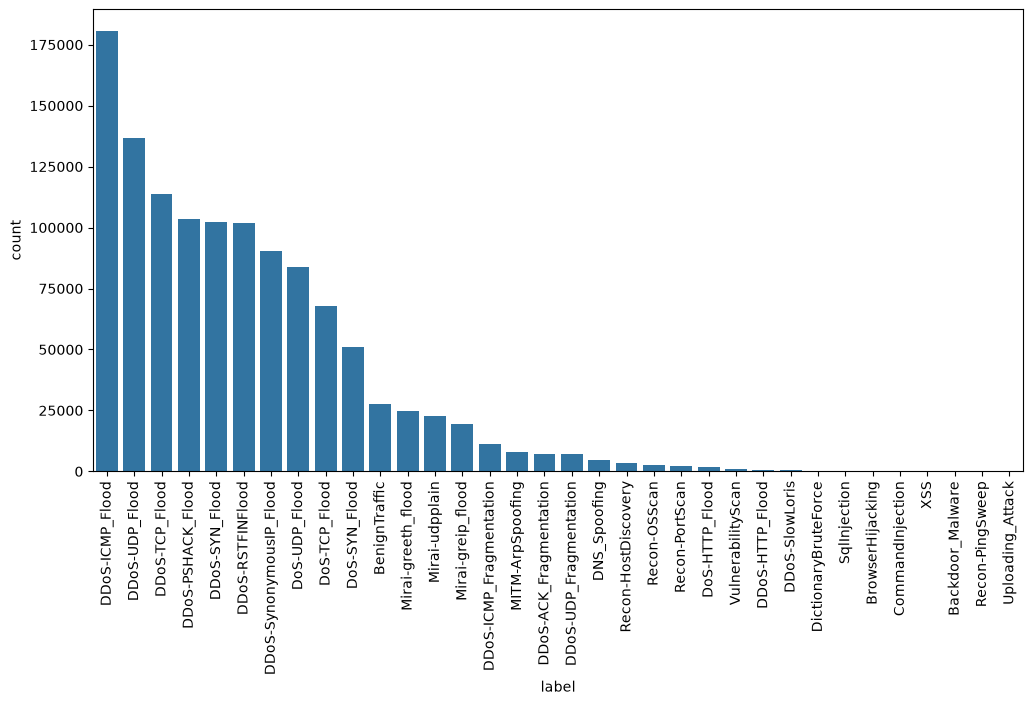

In [60]:
#Анализ распределения классов
#Посмотрим количество объектов каждого класса.

df["label"].value_counts()

#Построим визуализацию

plt.figure(figsize=(12,6))

sns.countplot(data=df,
              x="label",
              order=df["label"].value_counts().index)

plt.xticks(rotation=90)
plt.show()

In [ ]:
#По диаграмме видно, что атаки DDos преобладают над остальными

In [24]:
#Проверим числовые признаки
#Получим описание статистик.

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Rate,1176851.0,9.120311e+03,1.006035e+05,0.000000,2.098258e+00,1.586798e+01,1.191760e+02,8.388608e+06
Srate,1176851.0,9.120311e+03,1.006035e+05,0.000000,2.098258e+00,1.586798e+01,1.191760e+02,8.388608e+06
Drate,1176851.0,1.143707e-06,2.528345e-04,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.430061e-01
syn_flag_number,1176851.0,2.069914e-01,4.051495e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,1176851.0,9.045580e-02,2.868338e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
ack_flag_number,1176851.0,1.236716e-01,3.292066e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
HTTP,1176851.0,4.828904e-02,2.143764e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
HTTPS,1176851.0,5.541228e-02,2.287833e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
DNS,1176851.0,1.393549e-04,1.180405e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
Telnet,1176851.0,0.000000e+00,0.000000e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00


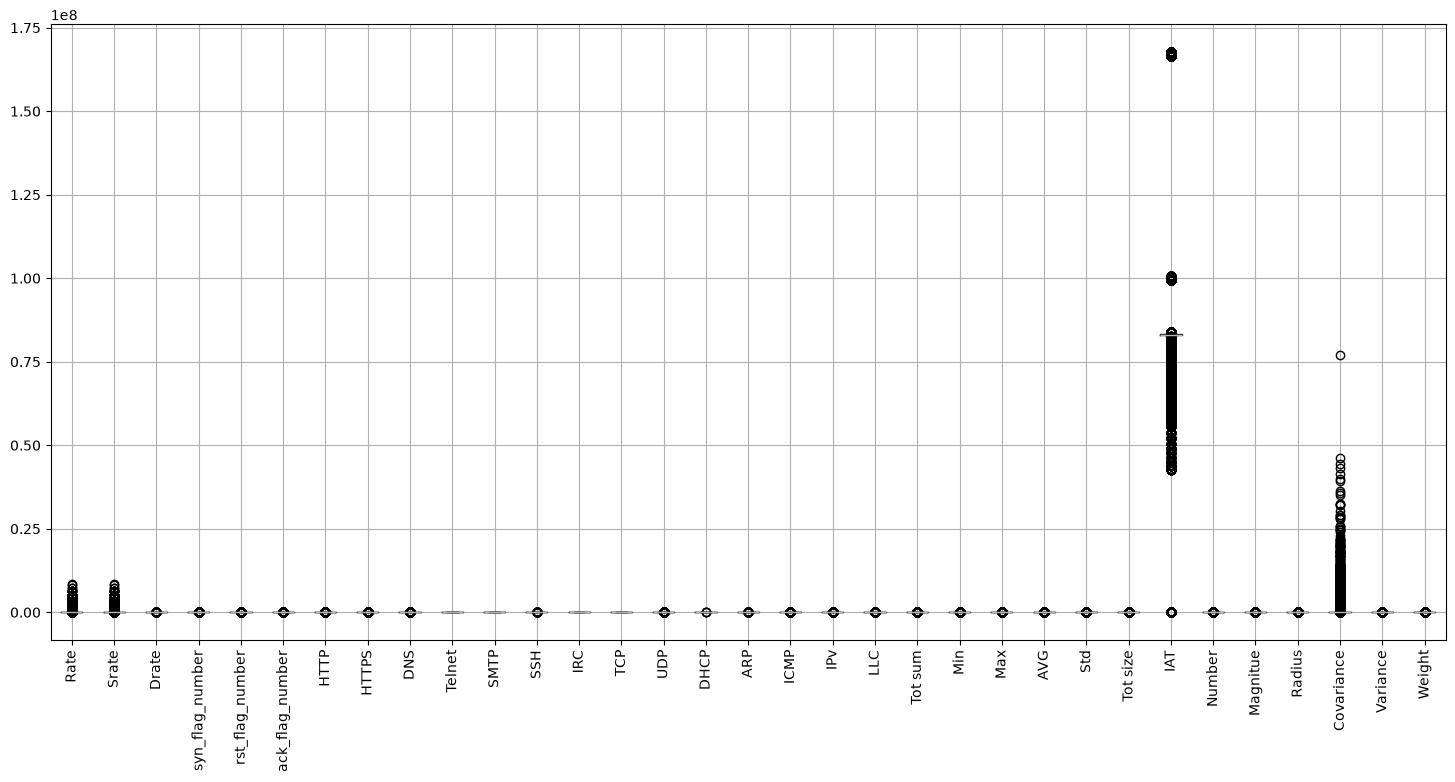

In [25]:
#Проверим выбросы


numeric = df.select_dtypes(include=np.number)

numeric.boxplot(figsize=(18,8))

plt.xticks(rotation=90)

plt.show()

In [26]:
#Проводим удаление неинформативных признаков
#Иногда имеются признаки, состоящие из одного значения.


for col in df.columns:
    print(col, df[col].nunique())

#Удаляем признаки

constant_columns = [
    col
    for col in df.columns
    if df[col].nunique() == 1
]

df.drop(columns=constant_columns,
        inplace=True)

Rate 962761
Srate 962761
Drate 74
syn_flag_number 2
rst_flag_number 2
ack_flag_number 2
HTTP 2
HTTPS 2
DNS 2
Telnet 1
SMTP 1
SSH 2
IRC 1
TCP 2
UDP 2
DHCP 2
ARP 2
ICMP 2
IPv 2
LLC 2
Tot sum 98716
Min 29094
Max 35348
AVG 192891
Std 180361
Tot size 37486
IAT 1168443
Number 96
Magnitue 188786
Radius 174400
Covariance 175227
Variance 378
Weight 102
label 34


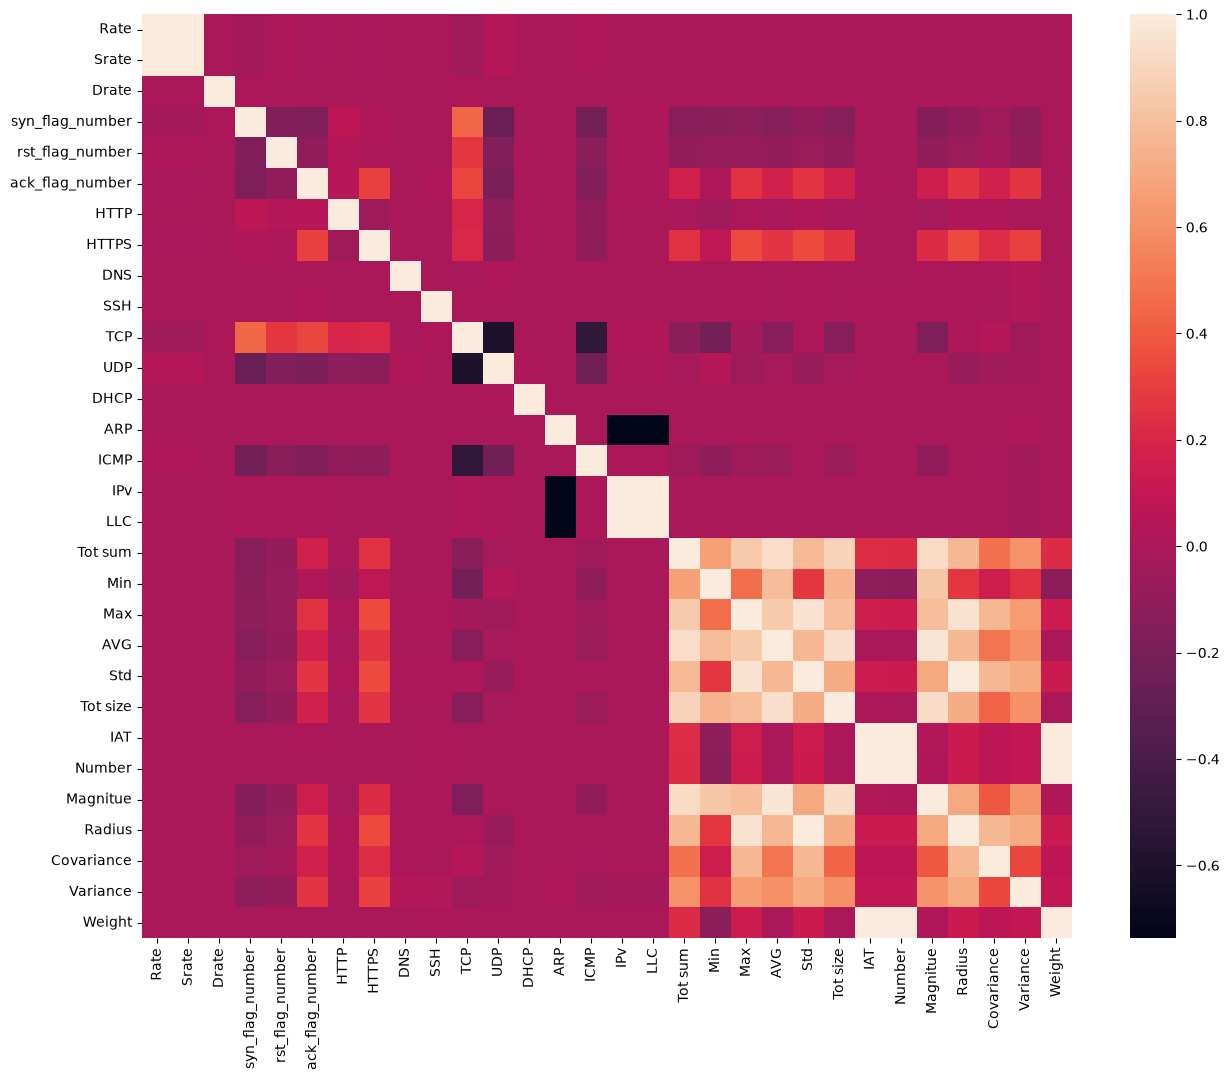

In [27]:
#Проверка корреляции
#Иногда несколько признаков бывают практически одинаковы.
#Построим корреляционную матрицу.

plt.figure(figsize=(15,12))

corr = df.corr(numeric_only=True)

sns.heatmap(corr)

plt.show()

In [28]:
#Проверка признаков с высокой корреляцией
corr_matrix = df.select_dtypes(include='number').corr()

high_corr = (
    corr_matrix
    .where(abs(corr_matrix) > 0.9)
    .stack()
    .reset_index()
)

high_corr.columns = ['feature_1', 'feature_2', 'correlation']

high_corr = high_corr[
    high_corr['feature_1'] != high_corr['feature_2']
]

print(high_corr)

    feature_1        feature_2  correlation
1        Rate            Srate     1.000000
2        Rate            Drate          NaN
3        Rate  syn_flag_number          NaN
4        Rate  rst_flag_number          NaN
5        Rate  ack_flag_number          NaN
..        ...              ...          ...
894    Weight           Number     0.999632
895    Weight         Magnitue          NaN
896    Weight           Radius          NaN
897    Weight       Covariance          NaN
898    Weight         Variance          NaN

[870 rows x 3 columns]


In [29]:
#По результатам проверким принимаем решение удалить State
df = df.drop(columns=['Srate'])

In [30]:
#Кодирование целевой переменной
#Возьмем Attack как целевую переменную
#Для бинарной классификации

Benign = 0

Attack = 1

df["Attack"] = df["label"].apply(
    lambda x: 0 if x == "Benign" else 1
)

#Если требуется многоклассовая классификация

encoder = LabelEncoder()

df["Attack"] = encoder.fit_transform(df["label"])

#Посмотреть соответствие

mapping = dict(
    zip(
        encoder.classes_,
        encoder.transform(encoder.classes_)
    )
)

print(mapping)


{'Backdoor_Malware': np.int64(0), 'BenignTraffic': np.int64(1), 'BrowserHijacking': np.int64(2), 'CommandInjection': np.int64(3), 'DDoS-ACK_Fragmentation': np.int64(4), 'DDoS-HTTP_Flood': np.int64(5), 'DDoS-ICMP_Flood': np.int64(6), 'DDoS-ICMP_Fragmentation': np.int64(7), 'DDoS-PSHACK_Flood': np.int64(8), 'DDoS-RSTFINFlood': np.int64(9), 'DDoS-SYN_Flood': np.int64(10), 'DDoS-SlowLoris': np.int64(11), 'DDoS-SynonymousIP_Flood': np.int64(12), 'DDoS-TCP_Flood': np.int64(13), 'DDoS-UDP_Flood': np.int64(14), 'DDoS-UDP_Fragmentation': np.int64(15), 'DNS_Spoofing': np.int64(16), 'DictionaryBruteForce': np.int64(17), 'DoS-HTTP_Flood': np.int64(18), 'DoS-SYN_Flood': np.int64(19), 'DoS-TCP_Flood': np.int64(20), 'DoS-UDP_Flood': np.int64(21), 'MITM-ArpSpoofing': np.int64(22), 'Mirai-greeth_flood': np.int64(23), 'Mirai-greip_flood': np.int64(24), 'Mirai-udpplain': np.int64(25), 'Recon-HostDiscovery': np.int64(26), 'Recon-OSScan': np.int64(27), 'Recon-PingSweep': np.int64(28), 'Recon-PortScan': np.

In [31]:
#Разделение признаков и целевой переменной
X = df.drop(columns=["label", "Attack"])

y = df["Attack"]

In [32]:
#Масштабирование признаков
#Для алгоритмов кластеризации и некоторых моделей важно привести признаки к единому масштабу.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

#Теперь каждый признак имеет:

#среднее значение около 0;
#стандартное отклонение около 1.

In [33]:
#Проверка готовности данных
print(X_scaled.shape)
print(y.shape)

(1176851, 29)
(1176851,)


label
DDoS-ICMP_Flood            15.33
DDoS-UDP_Flood             11.62
DDoS-TCP_Flood              9.66
DDoS-PSHACK_Flood           8.78
DDoS-SYN_Flood              8.68
DDoS-RSTFINFlood            8.65
DDoS-SynonymousIP_Flood     7.69
DoS-UDP_Flood               7.11
DoS-TCP_Flood               5.75
DoS-SYN_Flood               4.34
BenignTraffic               2.35
Mirai-greeth_flood          2.12
Mirai-udpplain              1.91
Mirai-greip_flood           1.64
DDoS-ICMP_Fragmentation     0.97
MITM-ArpSpoofing            0.67
DDoS-ACK_Fragmentation      0.62
DDoS-UDP_Fragmentation      0.61
DNS_Spoofing                0.39
Recon-HostDiscovery         0.28
Recon-OSScan                0.21
Recon-PortScan              0.18
DoS-HTTP_Flood              0.15
VulnerabilityScan           0.08
DDoS-HTTP_Flood             0.06
DDoS-SlowLoris              0.05
DictionaryBruteForce        0.03
SqlInjection                0.01
BrowserHijacking            0.01
CommandInjection            0.01
XSS 

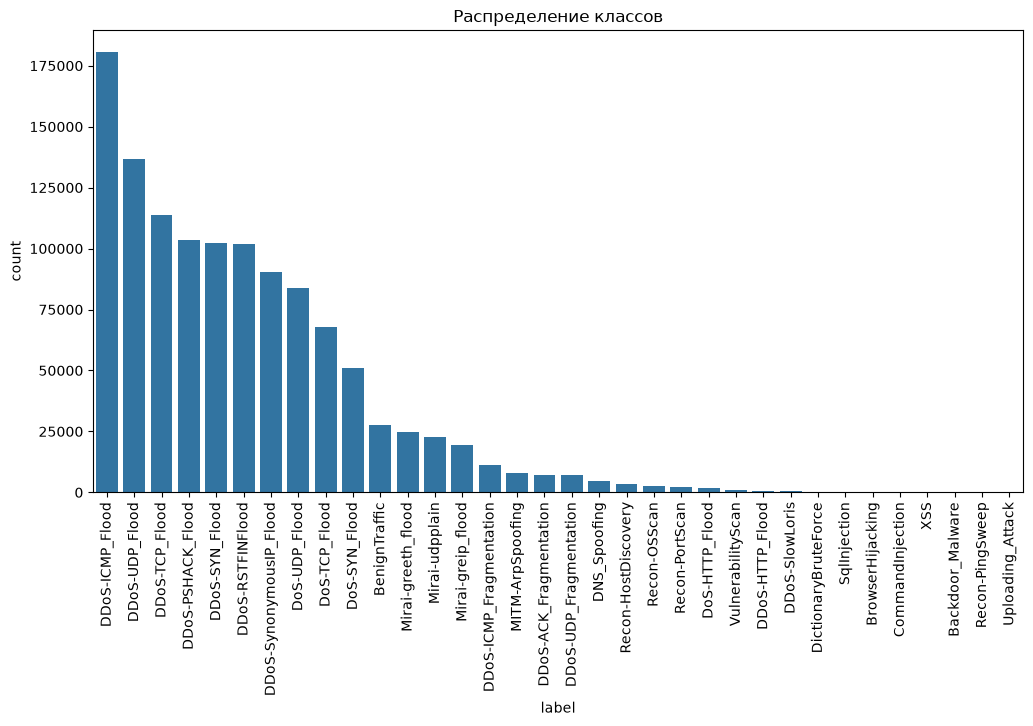

In [34]:
#Перед началом анализа посмотрим количество объектов каждого класса.

df["label"].value_counts()

#Также вычислим процентное соотношение классов.

class_distribution = (
    df["label"]
      .value_counts(normalize=True)
      .mul(100)
      .round(2)
)

print(class_distribution)
#Визуализация
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x="label",
    order=df["label"].value_counts().index
)

plt.xticks(rotation=90)

plt.title("Распределение классов")

plt.show()

In [ ]:
#Видим что все также ddos атаки преобладают над остальными видами атак

In [35]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Rate,1176851.0,9.120311e+03,1.006035e+05,0.000000,2.098258e+00,1.586798e+01,1.191760e+02,8.388608e+06
Drate,1176851.0,1.143707e-06,2.528345e-04,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.430061e-01
syn_flag_number,1176851.0,2.069914e-01,4.051495e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
rst_flag_number,1176851.0,9.045580e-02,2.868338e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
ack_flag_number,1176851.0,1.236716e-01,3.292066e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
HTTP,1176851.0,4.828904e-02,2.143764e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
HTTPS,1176851.0,5.541228e-02,2.287833e-01,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
DNS,1176851.0,1.393549e-04,1.180405e-02,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
SSH,1176851.0,5.183324e-05,7.199347e-03,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00
TCP,1176851.0,5.741483e-01,4.944717e-01,0.000000,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00


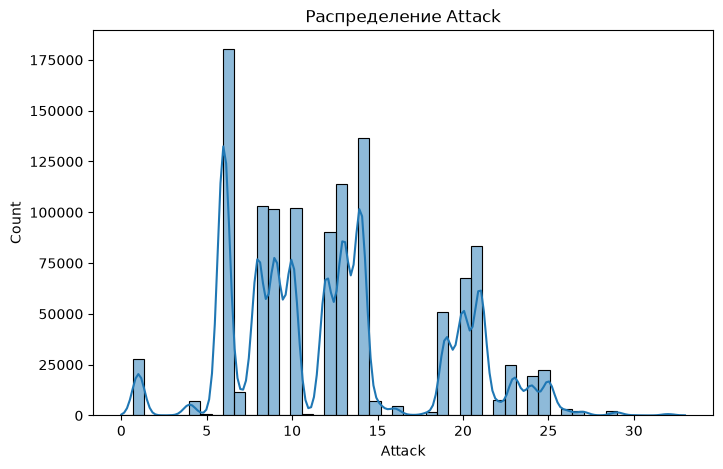

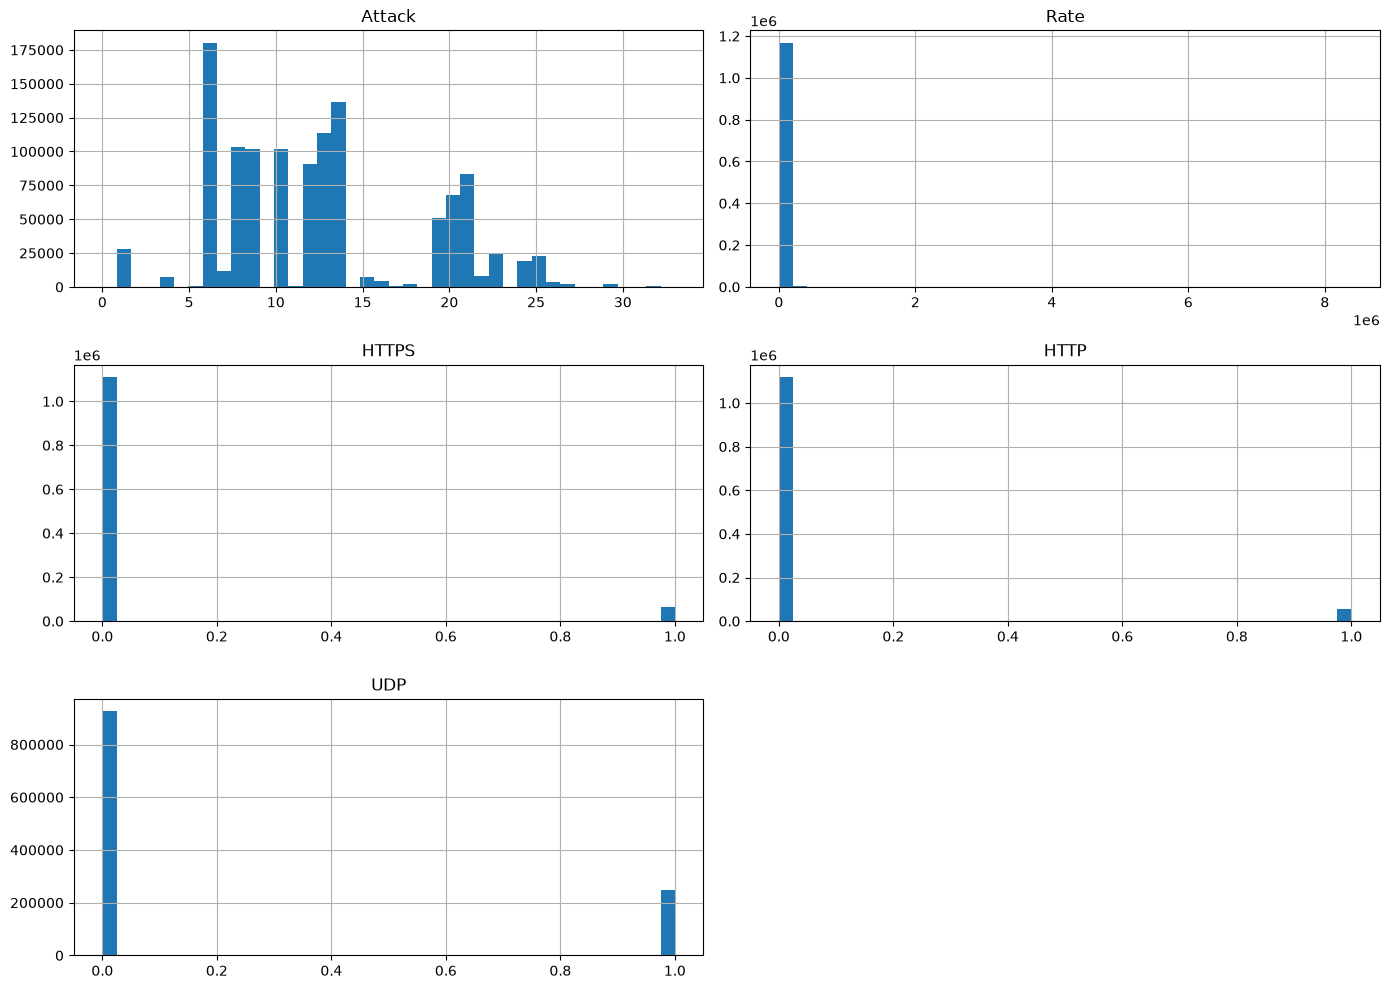

In [36]:
#Анализ распределения числовых признаков
#Изучим форму распределений.
#Например, для Attack.

plt.figure(figsize=(8,5))

sns.histplot(
    df["Attack"],
    bins=50,
    kde=True
)

plt.title("Распределение Attack")

plt.show()

#Сделам это для нескольких наиболее важных признаков.

columns = [
    "Attack",
    "Rate",
    "HTTPS",
    "HTTP",
    "UDP"
]

df[columns].hist(
    figsize=(14,10),
    bins=40
)

plt.tight_layout()

plt.show()

In [ ]:
'''По диаграмма видим что наибольшее значение находится в Attack'''

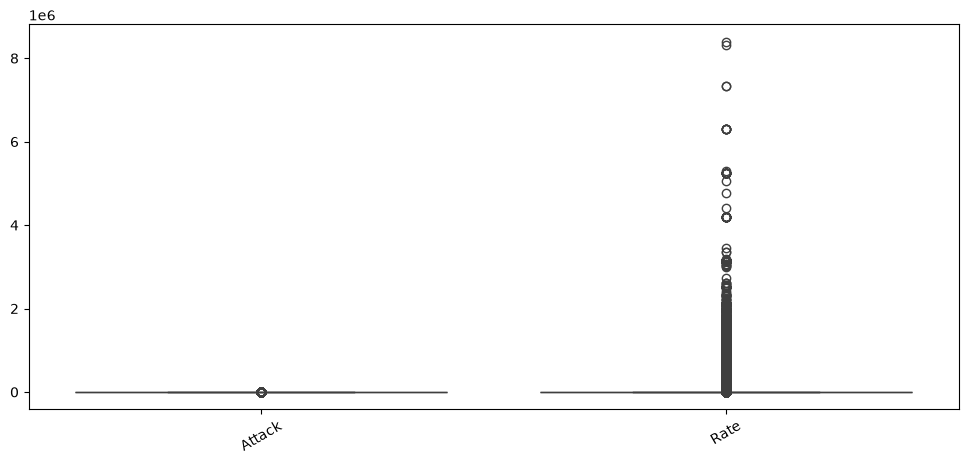

In [37]:
#Производим анализ выбросов
#Для обнаружения выбросов построим boxplot.

plt.figure(figsize=(12,5))

sns.boxplot(
    data=df[[
        "Attack",
        "Rate"
    ]]
)

plt.xticks(rotation=30)

plt.show()

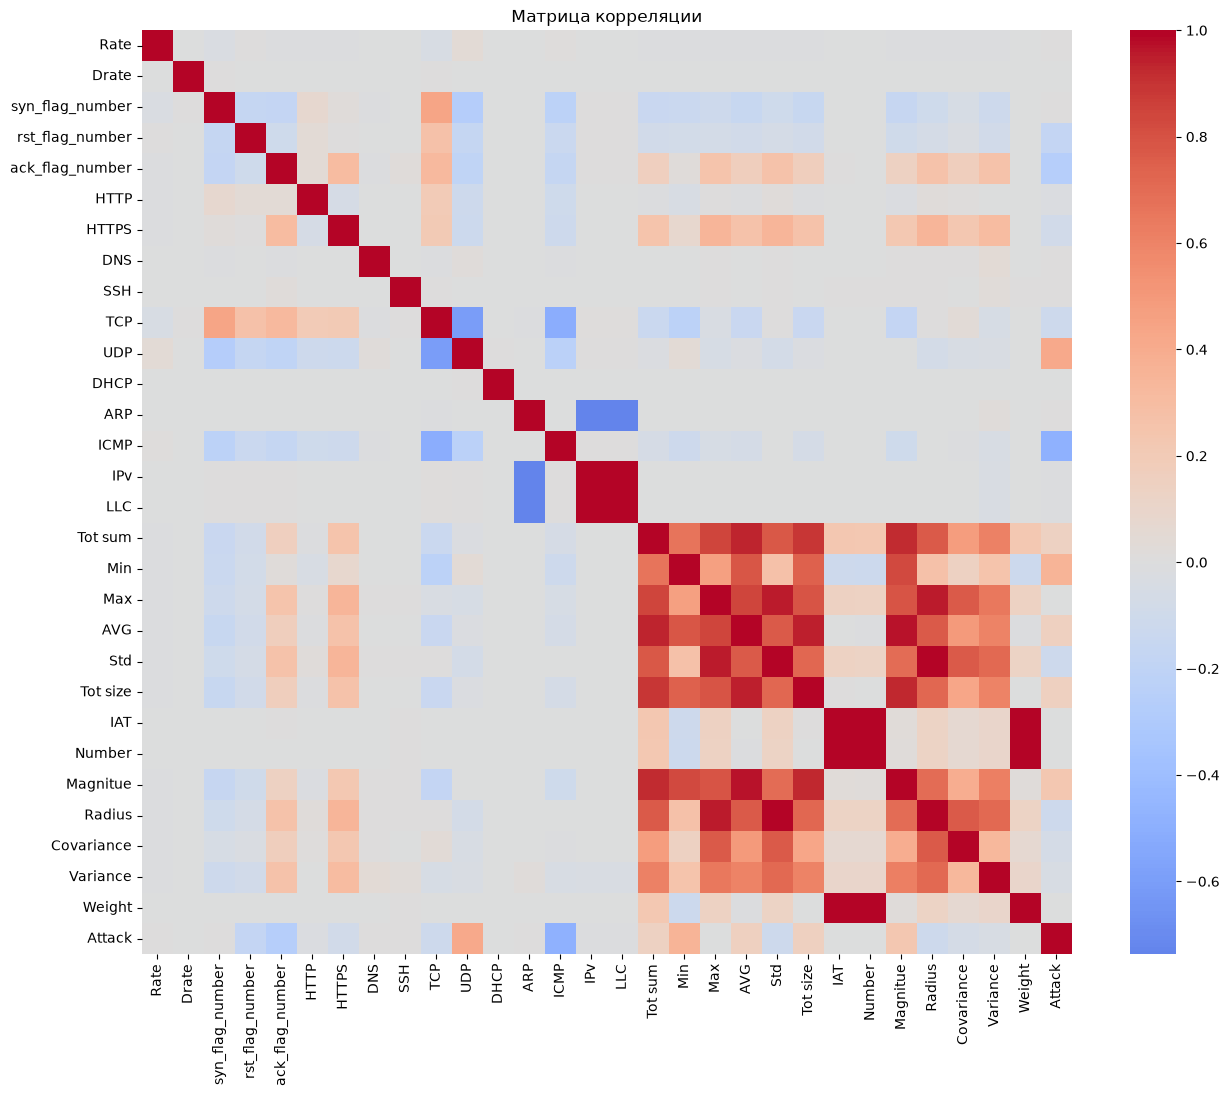

In [38]:
#Проводим анализ корреляции
#Вычислим корреляционную матрицу.

corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,12))

sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0
)

plt.title("Матрица корреляции")

plt.show()

In [ ]:
''' Наблюдаем сильную корреляцию между IAT,Number и Welght | magnitue и AVG, Tot_size | Radius и AVG, Tot_size'''

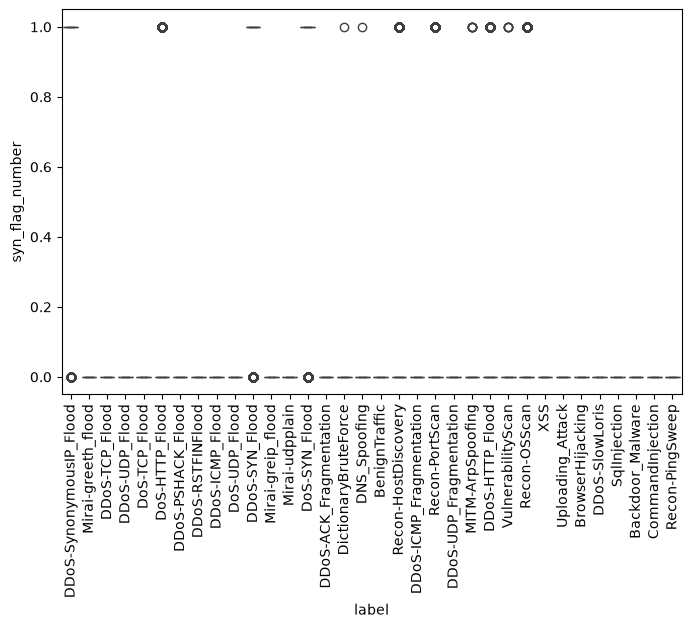

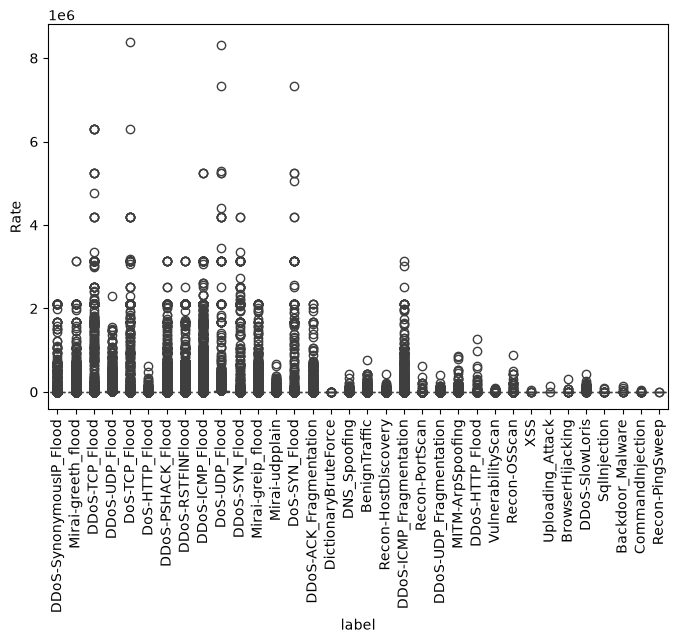

In [39]:
#Проводим анализ наиболее информативных признаков
#Рассмотрим распределения нескольких признаков отдельно для нормального и вредоносного трафика.

features = [
    "syn_flag_number",
    "Rate"
]

for feature in features:

    plt.figure(figsize=(8,5))

    sns.boxplot(
        data=df,
        x="label",
        y=feature
    )

    plt.xticks(rotation=90)

    plt.show()

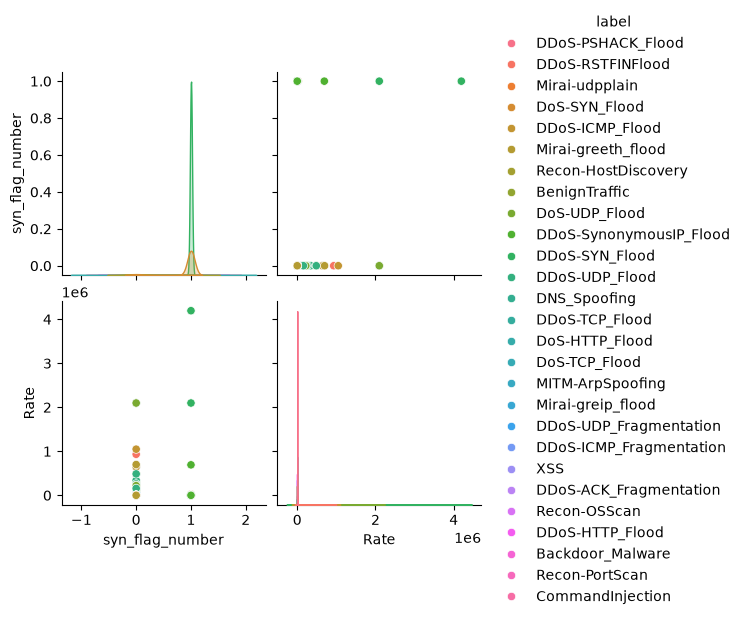

In [ ]:
#Pairplot
#Для небольшого количества признаков строим диаграмму рассеяния.

sample = df.sample(3000, random_state=42)

sns.pairplot(
    sample[
        [
            "syn_flag_number",
            "Rate",
            "label"
        ]
    ],
    hue="label"
)

plt.show()

In [ ]:
'''
Анализ Pairplot показал, что распределения некоторых признаков отличаются между классами сетевого трафика. 
В отдельных парах признаков наблюдается визуальное разделение классов, однако часть областей имеет значительное перекрытие. 
Это говорит о том, что отдельные признаки не всегда позволяют однозначно классифицировать тип трафика, 
но их комбинация может содержать значимую информацию для обнаружения атак.
'''

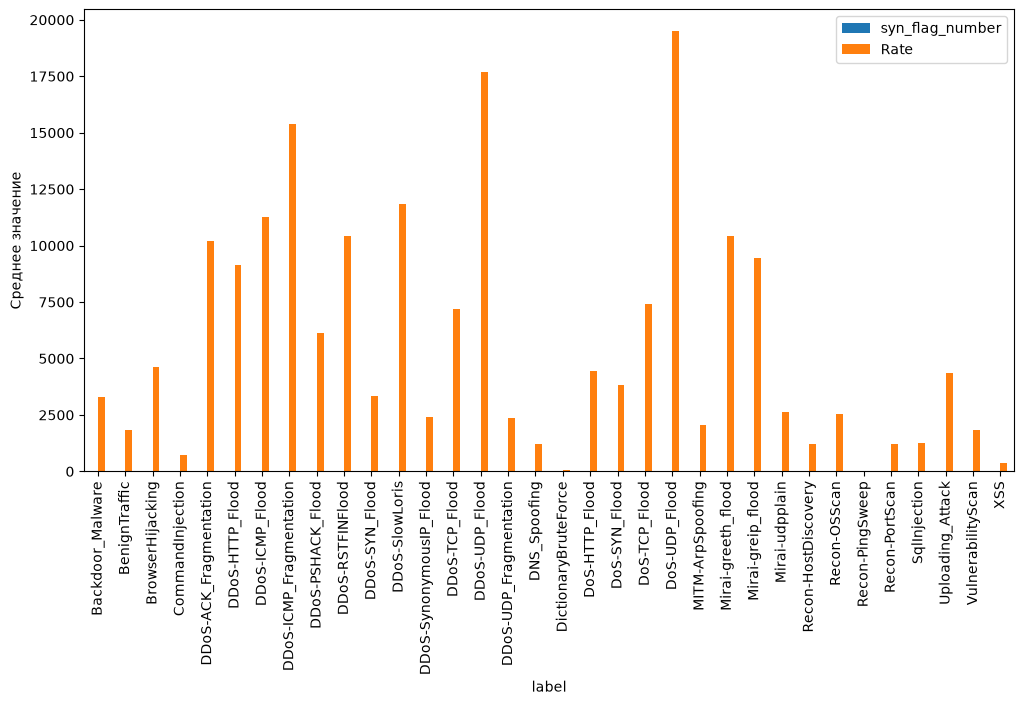

In [41]:
#Проводим анализ средней величины признаков
#Вычислим средние значения признаков для каждого класса.

group = (
    df
    .groupby("label")[
        [
            "syn_flag_number",
            "Rate"
        ]
    ]
    .mean()
)

group

#Визуализируем

group.plot(
    kind="bar",
    figsize=(12,6)
)

plt.ylabel("Среднее значение")

plt.show()

In [ ]:
'''На диаграмме видим, что Dos и DDos_UDP_Flood преобладают над другими типами атак.
Также видим большое значения для DDos-ICMP_Fragmentation '''

C:\Users\Спасибо за покупку!\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


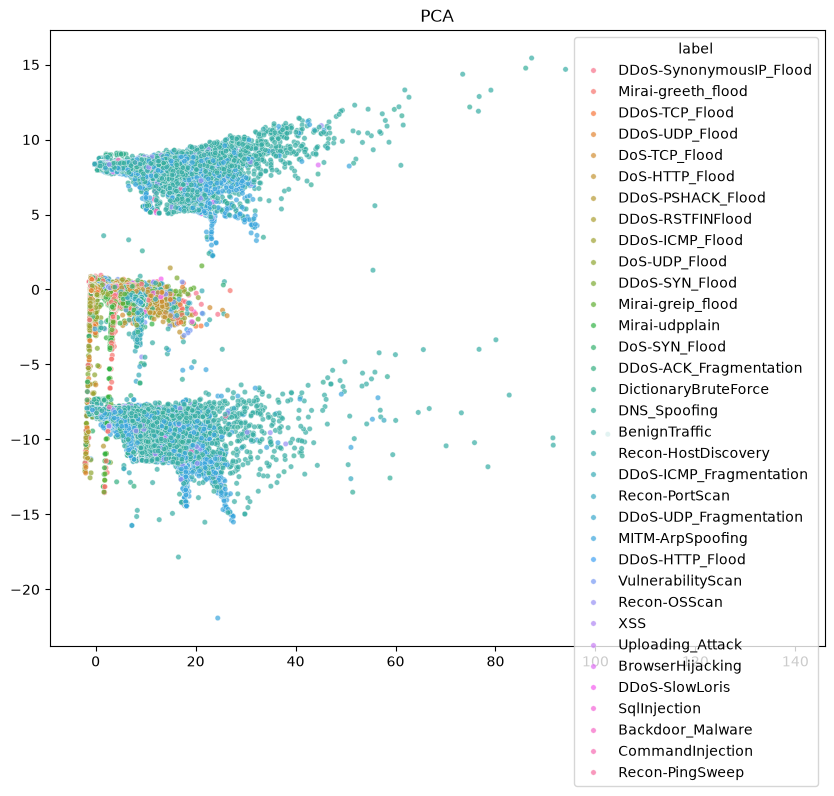

In [42]:
#Уменьшение размерности (PCA)
#Для визуализации многомерных данных используем PCA.

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

#Построим график.

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["label"],
    s=15,
    alpha=0.7
)

plt.title("PCA")

plt.show()

In [ ]:
'''
После снижения размерности методом PCA многомерные данные были представлены в пространстве главных компонент. 
На визуализации наблюдаются три выраженные области концентрации объектов, 
что свидетельствует о наличии в данных нескольких структурно различных групп. 
Это может указывать на существование различий между классами сетевого трафика или типами атак. 
При этом окончательная оценка качества разделения классов должна проводиться 
с учетом цветовой маркировки объектов по целевой переменной label и анализа взаимного перекрытия кластеров.
'''

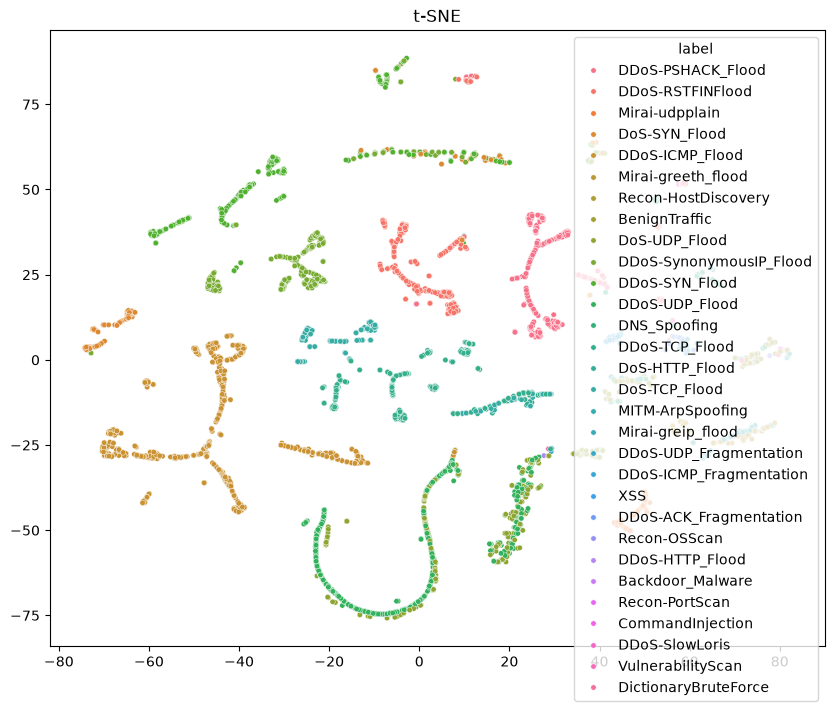

In [43]:
#Визуализация с помощью t-SNE
#PCA отображает только линейную структуру данных.
#Для исследования сложных зависимостей воспользуемся t-SNE.

from sklearn.manifold import TSNE

sample = df.sample(5000, random_state=42)

X_sample = sample.drop(columns=["label", "Attack"])

X_sample = StandardScaler().fit_transform(X_sample)

tsne = TSNE(
    n_components=2,
    random_state=42
)

X_tsne = tsne.fit_transform(X_sample)

#Визуализация.

plt.figure(figsize=(10,8))

sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=sample["label"],
    s=15
)

plt.title("t-SNE")

plt.show()

In [ ]:
'''
Полученная визуализация подтверждает, 
что задача классификации сетевого трафика имеет сложную многоклассовую структуру. 
Наличие как хорошо разделённых, так и пересекающихся областей обосновывает использование нескольких моделей машинного обучения
и последующее сравнение их способности различать близкие классы атак.
'''

In [ ]:
## Результаты EDA

In [ ]:
'''

В результате проведения разведочного анализа данных (EDA) была выполнена предварительная оценка качества и структуры датасета CICIoT2023, а также подготовка данных к дальнейшему этапу машинного обучения.

В ходе анализа были выполнены следующие работы:

Проведена проверка структуры данных, типов признаков и качества исходного датасета.
Выполнена проверка пропущенных значений. Существенных пропусков в признаках обнаружено не было, поэтому дополнительные методы заполнения пропусков не применялись.
Проведен анализ дубликатов и выполнена очистка данных от повторяющихся записей.
Выполнен анализ целевых признаков label и Attack. Был выявлен дисбаланс классов, связанный с различным количеством примеров для разных типов сетевых атак.
Проведен анализ распределения числовых признаков, в результате которого выявлено различие масштабов значений между параметрами сетевого трафика.
Выполнен анализ выбросов. Экстремальные значения признаков были сохранены, так как в контексте обнаружения атак они могут соответствовать реальным аномальным сетевым событиям.
Проведен корреляционный анализ числовых признаков для выявления взаимосвязанных и избыточных параметров.
Выполнен отбор признаков и удалены неинформативные параметры, а также признаки, способные привести к утечке целевой информации.
Проведен анализ категориальных и бинарных признаков, характеризующих используемые сетевые протоколы и особенности трафика (TCP, UDP, HTTP, HTTPS, DNS, SSH).
По результатам анализа было принято решение выполнить дальнейшую подготовку данных:
масштабирование числовых признаков для моделей, чувствительных к диапазону значений;
кодирование целевого признака;
учет дисбаланса классов при обучении моделей;
использование методов оценки важности признаков после обучения моделей.
Итоговый вывод:

Проведенный EDA показал, что датасет CICIoT2023 содержит информативные признаки, описывающие сетевое поведение IoT-устройств и характеристики атакующего трафика. Основными особенностями набора данных являются наличие дисбаланса классов, 
различный масштаб признаков и наличие коррелирующих параметров. После предварительной обработки датасет был подготовлен для построения моделей машинного обучения для задачи обнаружения и классификации сетевых атак.'''

In [ ]:
#Сохраним датасет для дальнейшего использования при обучении модели.

df.to_csv('data_model_diplom.csv', index=False)